Если окружение ещё не настроено:

```python
# %pip install pandas pyarrow numpy matplotlib seaborn scikit-learn jupyter ipykernel
```


In [14]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


In [15]:
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 5)

# Модифицируйте в соответствии со своей задачей
TRACK = "team"  # "solo" or "team"
TRAIN_DAYS = 14
MAX_TRAIN_ROWS = 1_500_000
RIDGE_ALPHA = 4.0
RANDOM_STATE = 42

# Меняйте конфигурацию при необходимости
TRACK_CONFIG = {
    "solo": {
        "train_path": "../raw/train_solo_track.parquet",
        "test_path": "../raw/test_solo_track.parquet",
        "target_col": "target_1h",
        "forecast_points": 8,
    },
    "team": {
        "train_path": "../raw/train_team_track.parquet",
        "test_path": "../raw/test_team_track.parquet",
        "target_col": "target_2h",
        "forecast_points": 10,
    },
}

CONFIG = TRACK_CONFIG[TRACK]
TARGET_COL = CONFIG["target_col"]
FORECAST_POINTS = CONFIG["forecast_points"]
FUTURE_TARGET_COLS = [f"target_step_{step}" for step in range(1, FORECAST_POINTS + 1)]


## Загрузка данных


In [16]:
train_df = pd.read_parquet(CONFIG["train_path"])
test_df = pd.read_parquet(CONFIG["test_path"])

train_df["timestamp"] = pd.to_datetime(train_df["timestamp"])
test_df["timestamp"] = pd.to_datetime(test_df["timestamp"])

train_df = train_df.sort_values(["route_id", "timestamp"]).reset_index(drop=True)
test_df = test_df.sort_values(["route_id", "timestamp"]).reset_index(drop=True)


def add_calendar_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df["hour"] = df["timestamp"].dt.hour
    df["minute"] = df["timestamp"].dt.minute
    df["dayofweek"] = df["timestamp"].dt.dayofweek
    df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)

    # Циклическое кодирование времени суток
    minutes_of_day = df["hour"] * 60 + df["minute"]
    df["tod_sin"] = np.sin(2 * np.pi * minutes_of_day / 1440)
    df["tod_cos"] = np.cos(2 * np.pi * minutes_of_day / 1440)

    # Циклическое кодирование дня недели
    df["dow_sin"] = np.sin(2 * np.pi * df["dayofweek"] / 7)
    df["dow_cos"] = np.cos(2 * np.pi * df["dayofweek"] / 7)

    return df


train_df = add_calendar_features(train_df)
test_df = add_calendar_features(test_df)

print("track:", TRACK)
print("train shape:", train_df.shape)
print("test shape:", test_df.shape)


track: team
train shape: (4342000, 20)
test shape: (10000, 11)


In [17]:
display(train_df.head())
display(test_df.head())


,office_from_id,route_id,timestamp,status_1,status_2,status_3,status_4,status_5,status_6,status_7,status_8,target_2h,hour,minute,dayofweek,is_weekend,tod_sin,tod_cos,dow_sin,dow_cos
0,26,0,2025-03-01 00:00:00,0,46,0,0,12,9,0,0,79.0,0,0,5,1,0.000000,1.000000,-0.974928,-0.222521
1,26,0,2025-03-01 00:30:00,0,34,0,0,16,0,187,0,88.0,0,30,5,1,0.130526,0.991445,-0.974928,-0.222521
2,26,0,2025-03-01 01:00:00,0,19,0,0,31,0,0,0,88.0,1,0,5,1,0.258819,0.965926,-0.974928,-0.222521
3,26,0,2025-03-01 01:30:00,0,33,0,0,36,129,0,0,88.0,1,30,5,1,0.382683,0.923880,-0.974928,-0.222521
4,26,0,2025-03-01 02:00:00,0,24,0,0,55,12,0,0,103.0,2,0,5,1,0.500000,0.866025,-0.974928,-0.222521


,id,route_id,timestamp,hour,minute,dayofweek,is_weekend,tod_sin,tod_cos,dow_sin,dow_cos
0,4900,0,2025-05-30 11:00:00,11,0,4,0,2.588190e-01,-0.965926,-0.433884,-0.900969
1,4901,0,2025-05-30 11:30:00,11,30,4,0,1.305262e-01,-0.991445,-0.433884,-0.900969
2,4902,0,2025-05-30 12:00:00,12,0,4,0,1.224647e-16,-1.000000,-0.433884,-0.900969
3,4903,0,2025-05-30 12:30:00,12,30,4,0,-1.305262e-01,-0.991445,-0.433884,-0.900969
4,4904,0,2025-05-30 13:00:00,13,0,4,0,-2.588190e-01,-0.965926,-0.433884,-0.900969


In [18]:
print("Train date range:", train_df["timestamp"].min(), "->", train_df["timestamp"].max())
print("Test date range:", test_df["timestamp"].min(), "->", test_df["timestamp"].max())
print("Train routes:", train_df["route_id"].nunique())
print("Test routes:", test_df["route_id"].nunique())


Train date range: 2025-03-01 00:00:00 -> 2025-05-30 10:30:00
Test date range: 2025-05-30 11:00:00 -> 2025-05-30 15:30:00
Train routes: 1000
Test routes: 1000


## EDA train-данных


In [19]:
overview = pd.DataFrame(
    {
        "dtype": train_df.dtypes.astype(str),
        "missing_cnt": train_df.isna().sum(),
        "missing_pct": (train_df.isna().mean() * 100).round(4),
        "n_unique": train_df.nunique(dropna=False),
    }
)
overview


,dtype,missing_cnt,missing_pct,n_unique
office_from_id,int64,0,0.0,53
route_id,int64,0,0.0,1000
timestamp,datetime64[ns],0,0.0,4342
status_1,int64,0,0.0,19752
status_2,int64,0,0.0,2127
status_3,int64,0,0.0,17998
status_4,int64,0,0.0,14416
status_5,int64,0,0.0,17108
status_6,int64,0,0.0,17616
status_7,int64,0,0.0,38219


In [20]:
status_cols = sorted([col for col in train_df.columns if col.startswith("status_")])
print("Status columns:", status_cols)
print("Target column:", TARGET_COL)
print("Forecast points:", FORECAST_POINTS)


Status columns: ['status_1', 'status_2', 'status_3', 'status_4', 'status_5', 'status_6', 'status_7', 'status_8']
Target column: target_2h
Forecast points: 10


## Распределения


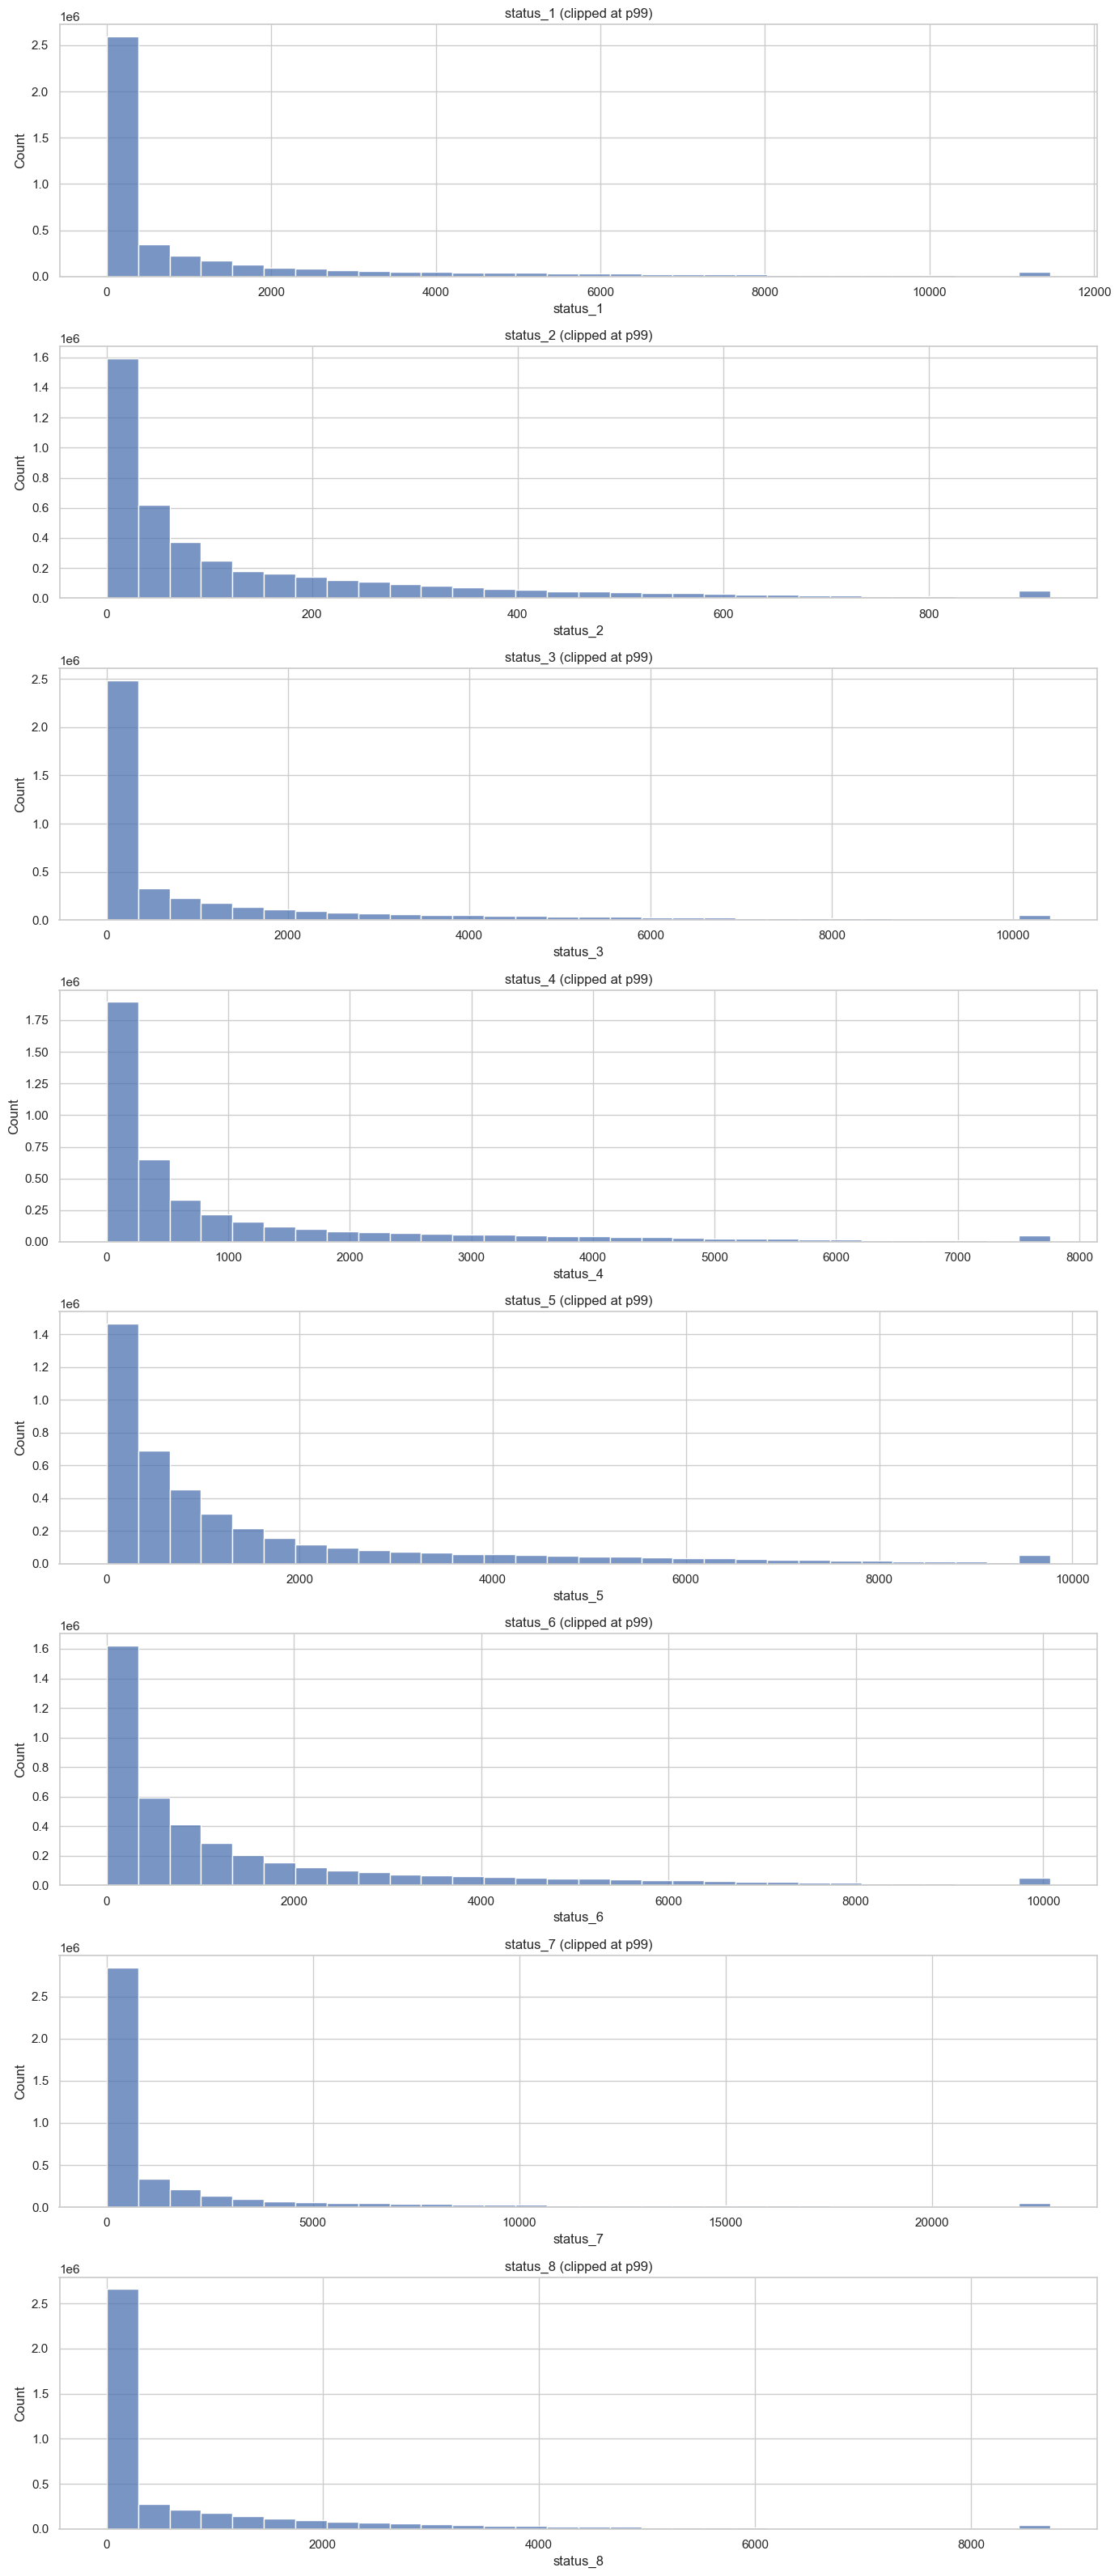

In [21]:
fig, axes = plt.subplots(len(status_cols), 1, figsize=(14, 4 * len(status_cols)))

if len(status_cols) == 1:
    axes = [axes]

for i, col in enumerate(status_cols):
    sns.histplot(train_df[col].clip(upper=train_df[col].quantile(0.99)), bins=30, ax=axes[i], kde=False)
    axes[i].set_title(f"{col} (clipped at p99)")

plt.tight_layout()
plt.show()


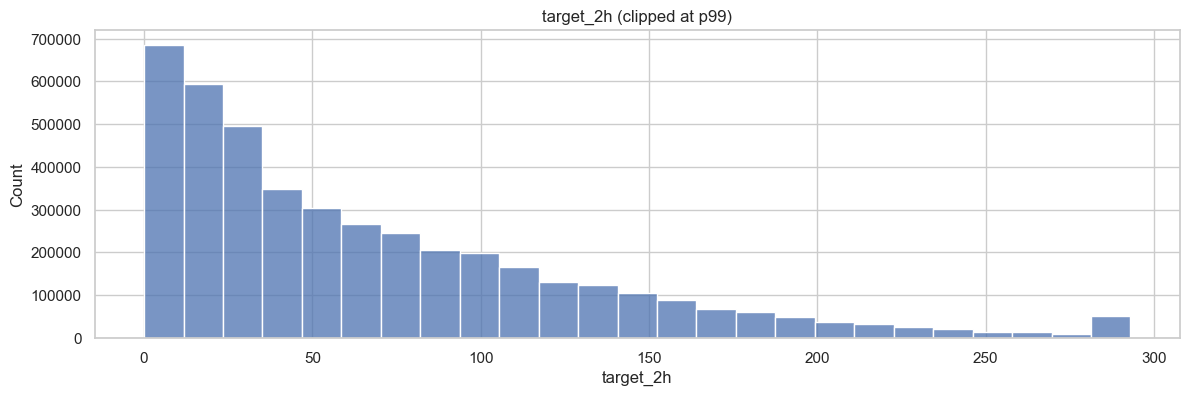

In [22]:
plt.figure(figsize=(14, 4))
sns.histplot(train_df[TARGET_COL].clip(upper=train_df[TARGET_COL].quantile(0.99)), bins=25, kde=False)
plt.title(f"{TARGET_COL} (clipped at p99)")
plt.show()


## лаги + rolling

In [23]:
route_group = train_df.groupby("route_id", sort=False)

# лаги по таргету
for lag in [1, 2, 4, 8, 48]:
    train_df[f"{TARGET_COL}_lag_{lag}"] = route_group[TARGET_COL].shift(lag)

# rolling-статистики только по прошлому
for window in [2, 4, 8, 48]:
    train_df[f"{TARGET_COL}_roll_mean_{window}"] = route_group[TARGET_COL].transform(
        lambda s: s.shift(1).rolling(window, min_periods=1).mean()
    )
    train_df[f"{TARGET_COL}_roll_std_{window}"] = route_group[TARGET_COL].transform(
        lambda s: s.shift(1).rolling(window, min_periods=2).std()
    )

# лаги по status_*
status_cols = [c for c in train_df.columns if c.startswith("status_")]

train_df["status_sum"] = train_df[status_cols].sum(axis=1)
for lag in [1, 2, 4]:
    train_df[f"status_sum_lag_{lag}"] = train_df.groupby("route_id")["status_sum"].shift(lag)

for col in status_cols:
    for lag in [1, 2]:
        train_df[f"{col}_lag_{lag}"] = route_group[col].shift(lag)

# разница между текущей суммой status и значением lag=1
train_df["status_sum_delta_1"] = train_df["status_sum"] - train_df["status_sum_lag_1"]


## Генерируем будущие таргеты


In [24]:
for step in range(1, FORECAST_POINTS + 1):
    train_df[f"target_step_{step}"] = route_group[TARGET_COL].shift(-step)

train_df[["route_id", "timestamp", TARGET_COL] + FUTURE_TARGET_COLS].head(10)


,route_id,timestamp,target_2h,target_step_1,target_step_2,target_step_3,target_step_4,target_step_5,target_step_6,target_step_7,target_step_8,target_step_9,target_step_10
0,0,2025-03-01 00:00:00,79.0,88.0,88.0,88.0,103.0,94.0,106.0,127.0,33.0,33.0,27.0
1,0,2025-03-01 00:30:00,88.0,88.0,88.0,103.0,94.0,106.0,127.0,33.0,33.0,27.0,6.0
2,0,2025-03-01 01:00:00,88.0,88.0,103.0,94.0,106.0,127.0,33.0,33.0,27.0,6.0,6.0
3,0,2025-03-01 01:30:00,88.0,103.0,94.0,106.0,127.0,33.0,33.0,27.0,6.0,6.0,6.0
4,0,2025-03-01 02:00:00,103.0,94.0,106.0,127.0,33.0,33.0,27.0,6.0,6.0,6.0,0.0
5,0,2025-03-01 02:30:00,94.0,106.0,127.0,33.0,33.0,27.0,6.0,6.0,6.0,0.0,0.0
6,0,2025-03-01 03:00:00,106.0,127.0,33.0,33.0,27.0,6.0,6.0,6.0,0.0,0.0,0.0
7,0,2025-03-01 03:30:00,127.0,33.0,33.0,27.0,6.0,6.0,6.0,0.0,0.0,0.0,31.0
8,0,2025-03-01 04:00:00,33.0,33.0,27.0,6.0,6.0,6.0,0.0,0.0,0.0,31.0,92.0
9,0,2025-03-01 04:30:00,33.0,27.0,6.0,6.0,6.0,0.0,0.0,0.0,31.0,92.0,92.0


In [25]:
supervised_df = train_df.dropna(subset=FUTURE_TARGET_COLS).copy()
print("Rows with future targets:", supervised_df.shape)


Rows with future targets: (4332000, 63)


## Корреляции


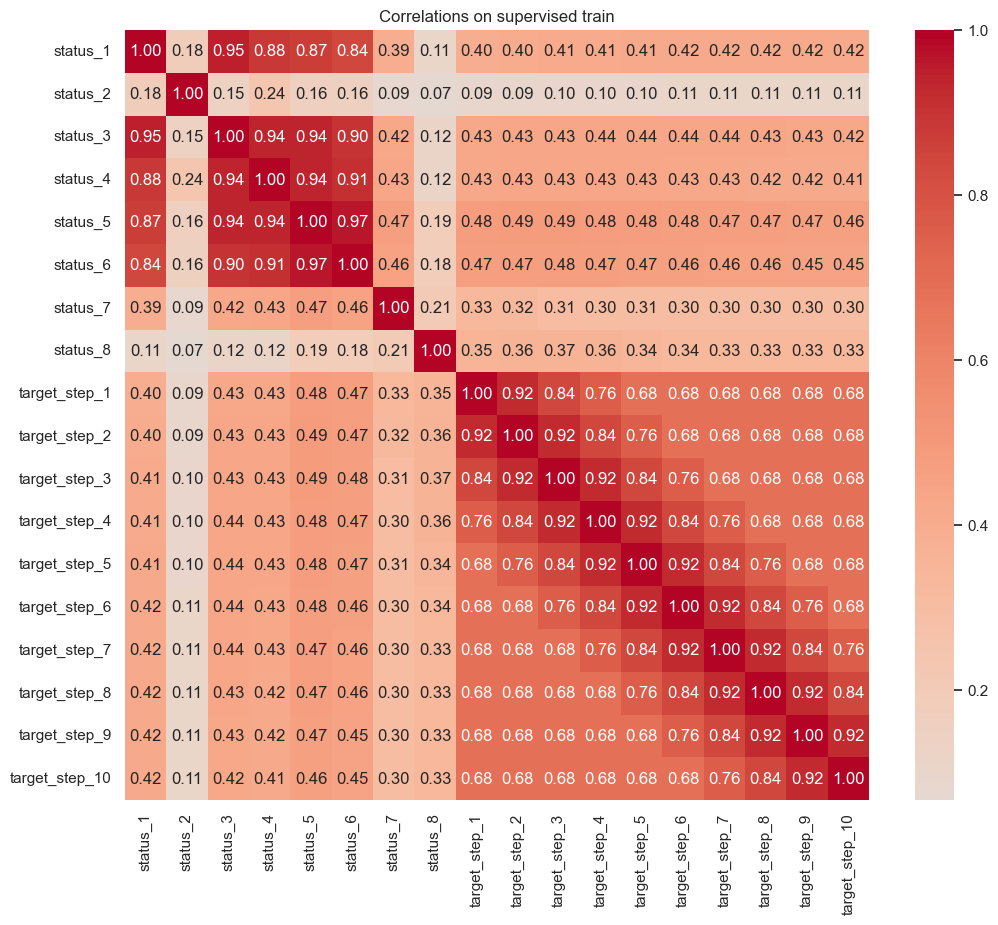

In [26]:
corr_cols = status_cols + FUTURE_TARGET_COLS
corr = supervised_df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlations on supervised train")
plt.show()


## Подготовка train и test


In [27]:
# Формируем 4 блока признаков для лёгкой абляции.
# Важно: никаких экзотических/ratio/interaction признаков - только то, что уже создаётся в feature engineering.

def uniq(seq):
    seen = set()
    out = []
    for x in seq:
        if x not in seen:
            out.append(x)
            seen.add(x)
    return out

# Базовые группы
status_cols = [f"status_{i}" for i in range(1, 9) if f"status_{i}" in train_df.columns]
calendar_cols = [
    "hour",
    "minute",
    "dayofweek",
    "is_weekend",
    "tod_sin",
    "tod_cos",
    "dow_sin",
    "dow_cos",
]
calendar_cols = [c for c in calendar_cols if c in train_df.columns]

# Лаги target
lag_steps = [1, 2, 4, 8, 48]
target_lag_cols = [f"{TARGET_COL}_lag_{lag}" for lag in lag_steps if f"{TARGET_COL}_lag_{lag}" in train_df.columns]

# Rolling по target
roll_windows = [2, 4, 8, 48]
target_roll_cols = []
for w in roll_windows:
    c1 = f"{TARGET_COL}_roll_mean_{w}"
    c2 = f"{TARGET_COL}_roll_std_{w}"
    if c1 in train_df.columns:
        target_roll_cols.append(c1)
    if c2 in train_df.columns:
        target_roll_cols.append(c2)

# История status
status_sum_cols = [
    "status_sum",
    "status_sum_lag_1",
    "status_sum_lag_2",
    "status_sum_lag_4",
]
status_sum_cols = [c for c in status_sum_cols if c in train_df.columns]

status_i_lags_cols = []
for i in range(1, 9):
    for lag in [1, 2]:
        col = f"status_{i}_lag_{lag}"
        if col in train_df.columns:
            status_i_lags_cols.append(col)

status_sum_delta_cols = [c for c in ["status_sum_delta_1"] if c in train_df.columns]

# Сами блоки абляции
block_A = uniq([c for c in ["route_id", "office_from_id", *status_cols, *calendar_cols] if c in train_df.columns])
block_B = uniq(block_A + target_lag_cols)
block_C = uniq(block_B + target_roll_cols)
block_D = uniq(block_C + status_sum_cols + status_i_lags_cols + status_sum_delta_cols)

feature_blocks = {
    "baseline_calendar_status": block_A,
    "+target_lags": block_B,
    "+target_rolling": block_C,
    "+status_history": block_D,
}

# Финальная модель для submission: используем самый полный блок D.
feature_cols = feature_blocks["+status_history"]

print("Feature columns (block D):", feature_cols)
print("n_features:", len(feature_cols))


Feature columns: ['office_from_id', 'route_id', 'status_1', 'status_2', 'status_3', 'status_4', 'status_5', 'status_6', 'status_7', 'status_8', 'hour', 'minute', 'dayofweek', 'is_weekend', 'tod_sin', 'tod_cos', 'dow_sin', 'dow_cos', 'target_2h_lag_1', 'target_2h_lag_2', 'target_2h_lag_4', 'target_2h_lag_8', 'target_2h_lag_48', 'target_2h_roll_mean_2', 'target_2h_roll_std_2', 'target_2h_roll_mean_4', 'target_2h_roll_std_4', 'target_2h_roll_mean_8', 'target_2h_roll_std_8', 'target_2h_roll_mean_48', 'target_2h_roll_std_48', 'status_sum', 'status_sum_lag_1', 'status_sum_lag_2', 'status_sum_lag_4', 'status_1_lag_1', 'status_1_lag_2', 'status_2_lag_1', 'status_2_lag_2', 'status_3_lag_1', 'status_3_lag_2', 'status_4_lag_1', 'status_4_lag_2', 'status_5_lag_1', 'status_5_lag_2', 'status_6_lag_1', 'status_6_lag_2', 'status_7_lag_1', 'status_7_lag_2', 'status_8_lag_1', 'status_8_lag_2']


In [28]:
train_model_df = supervised_df[feature_cols + ["timestamp"] + FUTURE_TARGET_COLS].copy()
train_model_df = train_model_df.rename(columns={"timestamp": "source_timestamp"})

train_ts_max = train_model_df["source_timestamp"].max()
train_window_start = train_ts_max - pd.Timedelta(days=TRAIN_DAYS)
train_model_df = train_model_df[train_model_df["source_timestamp"] >= train_window_start].copy()

print("Recent train rows:", train_model_df.shape)


Recent train rows: (673000, 62)


In [29]:
# последний момент факта, из которого делаем прогноз
# Берём максимальный timestamp: при корректной подготовке данных это даёт последнюю "срезовую" строку для каждого route_id.
inference_ts = train_df["timestamp"].max()
test_model_df = train_df[train_df["timestamp"] == inference_ts]

print("Test rows:", test_model_df.shape)


Test rows: (1000, 63)


## Time-based split


In [30]:
train_model_df = train_model_df.sort_values("source_timestamp").copy()

# Более честный time-based split:
# - valid берём как последние 2 дня относительно max(source_timestamp)
# - fit берём всё, что раньше
# - если 2 дня дают слишком мало данных, расширяем valid до последних 3 дней
max_ts = train_model_df["source_timestamp"].max()

VALID_DAYS = 2
MIN_VALID_ROWS = 10_000  # если нужно более жёстко/мягко, поменяйте порог

valid_start = max_ts - pd.Timedelta(days=VALID_DAYS)

valid_df = train_model_df[train_model_df["source_timestamp"] >= valid_start].copy()
fit_df = train_model_df[train_model_df["source_timestamp"] < valid_start].copy()

if len(valid_df) < MIN_VALID_ROWS:
    VALID_DAYS = 3
    valid_start = max_ts - pd.Timedelta(days=VALID_DAYS)
    valid_df = train_model_df[train_model_df["source_timestamp"] >= valid_start].copy()
    fit_df = train_model_df[train_model_df["source_timestamp"] < valid_start].copy()

# Никакого случайного sample: ограничиваем fit только по времени.
# Мы уже отсортировали train_model_df по source_timestamp, поэтому tail берёт самые свежие строки fit.
if len(fit_df) > MAX_TRAIN_ROWS:
    fit_df = fit_df.tail(MAX_TRAIN_ROWS).copy()

print("Time split valid_start:", valid_start)
print("Fit rows:", fit_df.shape)
print("Valid rows:", valid_df.shape)


Fit rows: (539000, 62)
Valid rows: (134000, 62)


In [31]:
X_fit = fit_df[feature_cols].copy()
y_fit = fit_df[FUTURE_TARGET_COLS].copy()

X_valid = valid_df[feature_cols].copy()
y_valid = valid_df[FUTURE_TARGET_COLS].copy()

X_test = test_model_df[feature_cols].copy()


## Линейный baseline


In [32]:
categorical_features = [col for col in feature_cols if col.endswith("_id")]
numeric_features = [col for col in feature_cols if col not in categorical_features]

print("Categorical features:", categorical_features)
print("Numeric features:", numeric_features)


Categorical features: ['office_from_id', 'route_id']
Numeric features: ['status_1', 'status_2', 'status_3', 'status_4', 'status_5', 'status_6', 'status_7', 'status_8', 'hour', 'minute', 'dayofweek', 'is_weekend', 'tod_sin', 'tod_cos', 'dow_sin', 'dow_cos', 'target_2h_lag_1', 'target_2h_lag_2', 'target_2h_lag_4', 'target_2h_lag_8', 'target_2h_lag_48', 'target_2h_roll_mean_2', 'target_2h_roll_std_2', 'target_2h_roll_mean_4', 'target_2h_roll_std_4', 'target_2h_roll_mean_8', 'target_2h_roll_std_8', 'target_2h_roll_mean_48', 'target_2h_roll_std_48', 'status_sum', 'status_sum_lag_1', 'status_sum_lag_2', 'status_sum_lag_4', 'status_1_lag_1', 'status_1_lag_2', 'status_2_lag_1', 'status_2_lag_2', 'status_3_lag_1', 'status_3_lag_2', 'status_4_lag_1', 'status_4_lag_2', 'status_5_lag_1', 'status_5_lag_2', 'status_6_lag_1', 'status_6_lag_2', 'status_7_lag_1', 'status_7_lag_2', 'status_8_lag_1', 'status_8_lag_2']


In [33]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_features,
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features,
        ),
    ]
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", Ridge(alpha=RIDGE_ALPHA)),
    ]
)


In [34]:
model.fit(X_fit, y_fit)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [35]:
fit_pred_df = pd.DataFrame(model.predict(X_fit), columns=FUTURE_TARGET_COLS, index=fit_df.index)
valid_pred_df = pd.DataFrame(model.predict(X_valid), columns=FUTURE_TARGET_COLS, index=valid_df.index)
test_pred_df = pd.DataFrame(model.predict(X_test), columns=FUTURE_TARGET_COLS, index=test_model_df.index)

valid_pred_df.head()


,target_step_1,target_step_2,target_step_3,target_step_4,target_step_5,target_step_6,target_step_7,target_step_8,target_step_9,target_step_10
3634110,21.228367,20.557548,24.129978,24.783679,24.946655,25.527075,26.091312,26.762447,27.639081,27.635658
807468,36.649279,52.340286,66.871065,66.299031,64.174955,63.761403,62.577020,62.323571,61.850678,61.567715
2066648,11.729386,13.039457,10.207838,11.184155,12.534606,13.535193,14.206613,15.204869,15.518004,15.966770
1276404,40.093823,32.813786,33.360760,33.654044,34.640401,36.052604,37.187624,38.386493,39.587924,40.325968
1840864,90.296745,93.325609,102.468290,105.750486,105.394444,107.161930,109.309557,112.235000,113.896420,115.354188


## Метрики


In [36]:
class WapePlusRbias:
    """Calculates as WAPE + Relative Bias."""

    @property
    def name(self) -> str:
        """Возвращает имя метрики."""
        return "wape_plus_rbias"

    def calculate(self, y_true: np.ndarray, y_pred: np.ndarray) -> float:
        """Рассчитывает значение метрики."""
        wape = (np.abs(y_pred - y_true)).sum() / y_true.sum()
        rbias = np.abs(y_pred.sum() / y_true.sum() - 1)
        return wape + rbias


metric = WapePlusRbias()

In [37]:
# Абляция по блокам признаков: проверяем вклад групп в метрику valid.
# Для каждого набора обучаем ту же Ridge-модель (multi-output) и считаем WapePlusRbias.

experiment_order = [
    "baseline_calendar_status",
    "+target_lags",
    "+target_rolling",
    "+status_history",
]

rows = []

for exp in experiment_order:
    block_features = feature_blocks[exp]
    n_features = len(block_features)

    if exp == "+status_history":
        # Финальная модель уже обучена в baseline-коде выше,
        # поэтому просто берём готовые предикты.
        fit_metric = metric.calculate(
            y_fit.to_numpy().flatten(),
            fit_pred_df.to_numpy().flatten(),
        )
        valid_metric = metric.calculate(
            y_valid.to_numpy().flatten(),
            valid_pred_df.to_numpy().flatten(),
        )
    else:
        categorical_features = [c for c in block_features if c.endswith("_id")]
        numeric_features = [c for c in block_features if c not in categorical_features]

        preprocessor = ColumnTransformer(
            transformers=[
                (
                    "num",
                    Pipeline(
                        steps=[
                            ("imputer", SimpleImputer(strategy="median")),
                            ("scaler", StandardScaler()),
                        ]
                    ),
                    numeric_features,
                ),
                (
                    "cat",
                    OneHotEncoder(handle_unknown="ignore"),
                    categorical_features,
                ),
            ]
        )

        model = Pipeline(
            steps=[
                ("preprocessor", preprocessor),
                ("regressor", Ridge(alpha=RIDGE_ALPHA)),
            ]
        )

        X_fit_block = fit_df[block_features].copy()
        y_fit_block = fit_df[FUTURE_TARGET_COLS].copy()

        X_valid_block = valid_df[block_features].copy()
        y_valid_block = valid_df[FUTURE_TARGET_COLS].copy()

        # Важно: перед predict нужно обучить модель.
        # Иначе получаем NotFittedError.
        model.fit(X_fit_block, y_fit_block)

        fit_pred_block = pd.DataFrame(
            model.predict(X_fit_block), columns=FUTURE_TARGET_COLS, index=fit_df.index
        )
        valid_pred_block = pd.DataFrame(
            model.predict(X_valid_block), columns=FUTURE_TARGET_COLS, index=valid_df.index
        )

        fit_metric = metric.calculate(
            y_fit_block.to_numpy().flatten(), fit_pred_block.to_numpy().flatten()
        )
        valid_metric = metric.calculate(
            y_valid_block.to_numpy().flatten(), valid_pred_block.to_numpy().flatten()
        )

    rows.append(
        {
            "experiment": exp,
            "n_features": n_features,
            "fit_metric": float(fit_metric),
            "valid_metric": float(valid_metric),
        }
    )

results_df = pd.DataFrame(rows)
results_df = results_df.sort_values("valid_metric", ascending=True).reset_index(drop=True)

# Таблица результатов абляции: сортировка по valid_metric по возрастанию.
print("Ablation results (sorted by valid_metric):")
display(results_df.round(6))


Метрики на тесте (по горизонтам):


target_step_1     0.22
target_step_2     0.25
target_step_3     0.28
target_step_4     0.29
target_step_5     0.29
target_step_6     0.29
target_step_7     0.29
target_step_8     0.29
target_step_9     0.29
target_step_10    0.29
dtype: float64

Общая метрика на тесте:
0.28


In [38]:
# Метрики финальной модели (блок +status_history) и все остальные абляции уже показаны в таблице выше.


Метрики на валидации (по горизонтам):


target_step_1     0.21
target_step_2     0.25
target_step_3     0.27
target_step_4     0.28
target_step_5     0.28
target_step_6     0.28
target_step_7     0.29
target_step_8     0.29
target_step_9     0.29
target_step_10    0.29
dtype: float64

Общая метрика на валидации:
0.27


## Конвертируем прогноз в нужный формат 


In [39]:
# добавляем к прогнозу маршруты
test_pred_df['route_id'] = X_test['route_id']

# разворачиваем target_step_* в строки
forecast_df = test_pred_df.melt(
    id_vars="route_id",
    value_vars=[c for c in test_pred_df.columns if c.startswith("target_step_")],
    var_name="step",
    value_name="forecast"
)

# достаем номер шага из target_step_1, target_step_2, ...
forecast_df["step_num"] = forecast_df["step"].str.extract(r"(\d+)").astype(int)

# строим timestamp: каждый шаг = +30 минут от времени прогноза
forecast_df["timestamp"] = inference_ts + pd.to_timedelta(forecast_df["step_num"] * 30, unit="m")

# оставляем нужные столбцы
forecast_df = forecast_df[["route_id", "timestamp", "forecast"]].sort_values(
    ["route_id", "timestamp"]
).reset_index(drop=True)

forecast_df = test_df.merge(forecast_df, 'outer')[["id", "forecast"]]
forecast_df = forecast_df.rename(columns={"forecast": "y_pred"})

In [40]:
forecast_df.head()

,id,y_pred
0,4900,12.008293
1,4901,17.686730
2,4902,24.961948
3,4903,26.080056
4,4904,24.922394


In [41]:
# проверяем, что все точки получены
assert forecast_df['id'].isna().sum() == 0


## Выгрузка CSV


In [49]:
submission_path =  f"../submissions/submission_{TRACK}.csv"
joined_path =  f"test_with_forecast_{TRACK}.csv"

forecast_df.to_csv(submission_path, index=False)

print("submission saved to:", submission_path)

submission saved to: ../submissions/submission_team.csv
